In [1]:
def AverageUnc(Up,Down):
    Average = (Up + Down)/2
    # mask = Average < percentage
    return Average 

#simplified form of stephan boltzman law
def Luminosity(Rad, Temp):
    return (Rad)**2 * (Temp)**4 #  Solar Units

def Lum_err(Rad,D_Rad,Temp,D_Temp):
    return Luminosity(Rad,Temp) * np.sqrt((D_Rad/Rad)**2 + (D_Temp/Temp)**2)

def Insol(Lum,a):
    return (Lum) * (1/a)**2 # Earth units

def Insol_err(Lum, D_lum, a, D_a):
    return Insol(Lum,a) * np.sqrt((D_lum/Lum)**2 + (D_a/a)**2)

In [2]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np, matplotlib.colors as mcolors

dtype_spec = {
    'column_name_4': 'str',
    'column_name_5': 'float'
}

Data = pd.read_csv("New_Stellar_host_mod.csv",dtype=dtype_spec, low_memory=False)
Dat= Data.drop_duplicates(subset="pl_name", keep="first").dropna(how='all').reset_index(drop=True)

radius = Dat["pl_radj"]
rad_err = [Dat["pl_radjerr1"], Dat["pl_radjerr2"]]
mass = Dat["pl_bmassj"]
mass_err = [Dat["pl_bmassjerr1"], Dat["pl_bmassjerr2"]]
mass_stellar = Dat["st_mass"]
rad_stellar = Dat["st_rad"]
Temp = Dat["st_teff"]
Temp_err =  [Dat["st_tefferr1"], Dat["st_tefferr2"]]
a = Dat["pl_orbsmax"]
Stellar_lum = Luminosity(rad_stellar/1,Temp/5777)
insol = Insol(Stellar_lum,a)

radii_uncertainty = (((rad_err[0]+rad_err[1]))/2)/radius *100
mass_uncertainty = (((mass_err[0]+mass_err[1])/2))/mass *100

mask = (radii_uncertainty < 10) & (mass_uncertainty < 20) & np.isfinite(insol)

Dat = Dat[mask].dropna(how='all').reset_index(drop=True)
radius_filtered = Dat["pl_radj"]
rad_err_filtered = [Dat["pl_radjerr1"], Dat["pl_radjerr2"]]
mass_filtered = Dat["pl_bmassj"]
mass_err_filtered = [Dat["pl_bmassjerr1"], Dat["pl_bmassjerr2"]]
mass_stellar_filtered = Dat["st_mass"]
rad_stellar_filtered = Dat["st_rad"]
Temp_filtered = Dat["st_teff"]
Temp_err_filtered =  [Dat["st_tefferr1"], Dat["st_tefferr2"]]
a_filtered = Dat["pl_orbsmax"]
a_err_filtered = [Dat["pl_orbsmaxerr1"],Dat["pl_orbsmaxerr2"]]

Stellar_lum = Luminosity(rad_stellar_filtered/1,Temp_filtered/5777)
Stellar_Lum_err = Lum_err(radius_filtered,(rad_err_filtered[0]+np.abs(rad_err_filtered[1]))/2,Temp_filtered/5777,((Temp_err_filtered[0]+np.abs(Temp_err_filtered[1]))/2)/5777)
insol = Insol(Stellar_lum,a_filtered)
insol_err = Insol_err(Stellar_lum,Stellar_Lum_err,a_filtered,(a_err_filtered[0]+np.abs(a_err_filtered[1]))/2)

In [3]:
from IPython.display import display, Math

mass_thres = 0.2
rad_thres = 0.2
KOI_6194b_mass = 240.1628/317.93842034806
KOI_6194b_radius = 9.829/10
mass_mask = (np.abs(mass_filtered - KOI_6194b_mass) <= mass_thres) #& (np.abs(radius_filtered - KOI_6194b_radius) <= rad_thres)
# rad_mask = np.abs(radius_filtered - KOI_6194b_radius) <= rad_thres

# print(np.mean(mass_filtered[mass_mask]))
print(np.mean(radius_filtered[mass_mask]))
print(np.std(radius_filtered[mass_mask]))

display(Math(r'\bar M = ({0:.3f} \pm {1:.3f}) R_J'.format(np.mean(radius_filtered[mass_mask]), np.std(radius_filtered[mass_mask]))))

1.206768115942029
0.23895273590796065


<IPython.core.display.Math object>

In [5]:
from IPython.display import display, Math

Lum = Luminosity(5.6323/1, 4725.29/5777)
Lumerr = Lum_err(5.6323/1, 0.0809/1,4725.29/5777,100/5777)
Insol_b = Insol(Lum,0.25469955)
Insol_b_err = Insol_err(Lum,Lumerr,0.25469955,0.0033)
display(Math(fr'L_* = ({Lum:.3f} \pm {Lumerr:.3f}) L_{{\odot}}'))
display(Math(fr'F_b = ({Insol_b:.3f} \pm {Insol_b_err:.3f}) F_{{\oplus}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

/var/folders/4v/jfc0xcx54rv11lmjnmw_dmvw0000gp/T/ipykernel_15469/2570988448.py:40: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(mass_filtered,radius_filtered, xerr = np.abs(mass_err_filtered),yerr = np.abs(rad_err_filtered),fmt='-',capsize=3,linestyle='',c='grey',zorder=-100)
/var/folders/4v/jfc0xcx54rv11lmjnmw_dmvw0000gp/T/ipykernel_15469/2570988448.py:54: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(insol,radius_filtered,xerr=np.abs(insol_err),yerr = np.abs(rad_err_filtered),fmt='-',capsize=3,linestyle='',c='grey',zorder=-100)
/var/folders/4v/jfc0xcx54rv11lmjnmw_dmvw0000gp/T/ipykernel_15469/2570988448.py:79: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (->

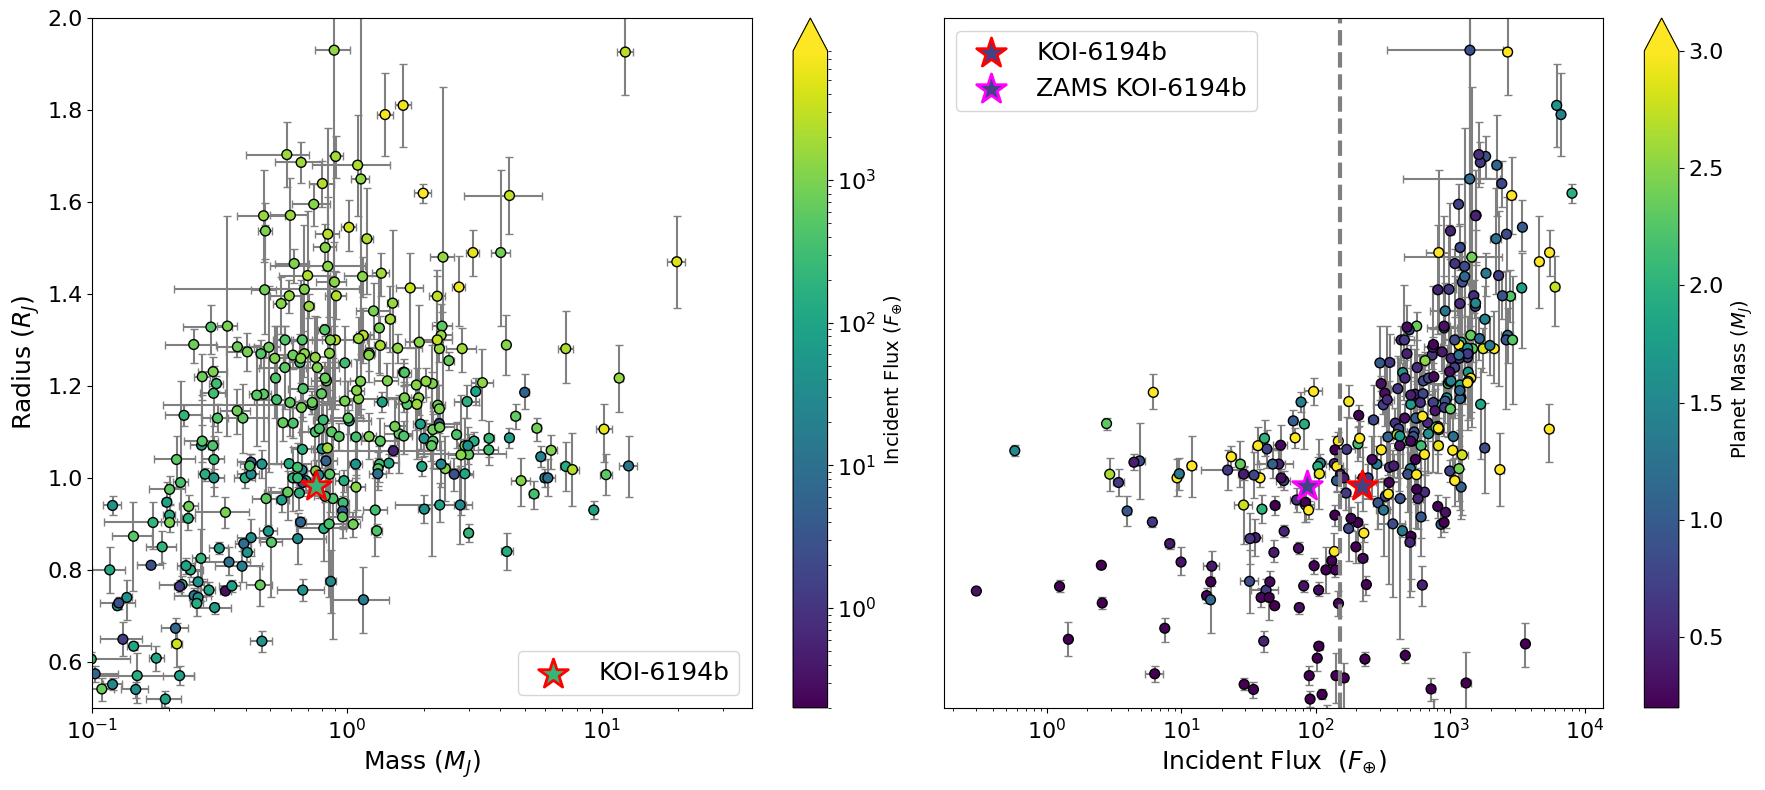

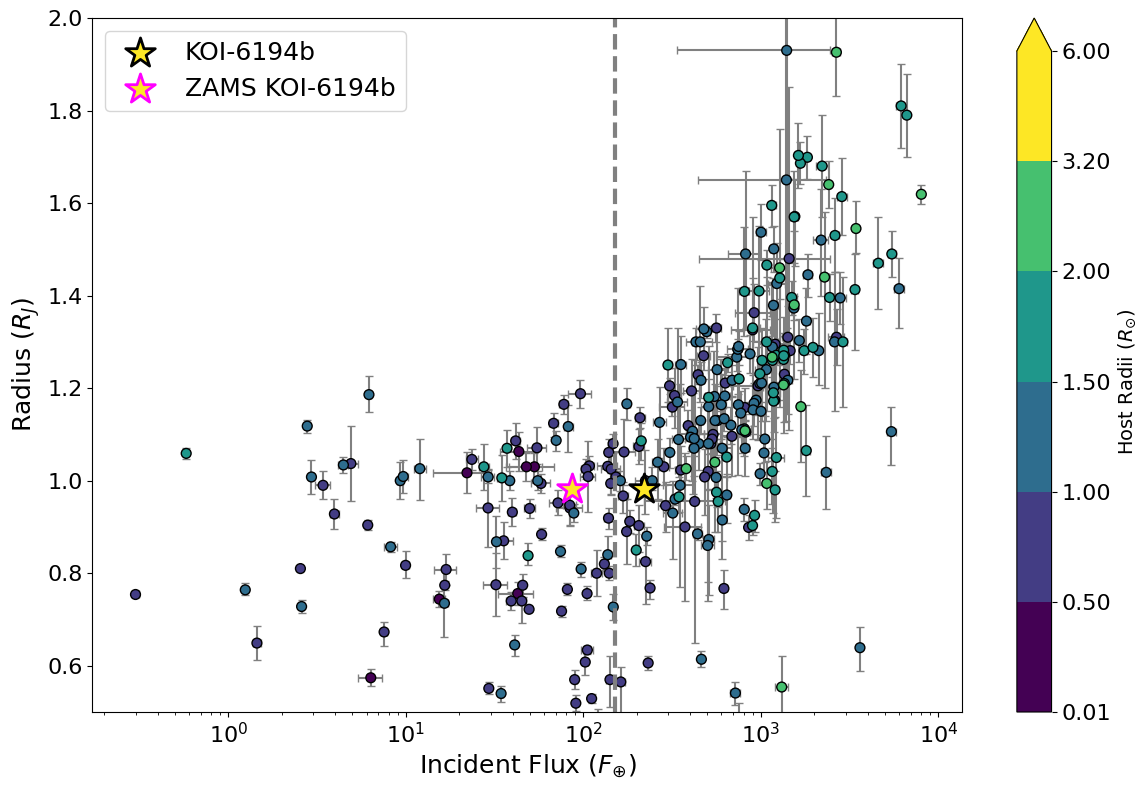

In [17]:
from matplotlib.patheffects import Normal
# from numpy import NaN
import matplotlib as mpl
from matplotlib import cm
import matplotlib.colors as clr
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm, Normalize, LinearSegmentedColormap, PowerNorm

%matplotlib inline
# [r,m,ecc,p,insol, teff, lambda]
KOI6194b = [9.829/10, 240.1628/317.93842034806,  0.1574, 42.2958,Insol_b,4725.29, 0]
KOI_rad = 5.632

predicted_zams_incident_flux = 86.528 # I_oplus
predicted_zams_stellar_rad = 3.817 # R_*
cmap = mpl.cm.viridis

def Plotting(x_val, y_val,KOI_valx, KOI_valy,colourbar,norm,star_mass,S,edgecolor,xtitle = "",ytitle="",logx=True,logy=True):
    scatter = ax.scatter(x_val, y_val, c=colourbar, cmap=cmap, s=S, norm=norm, edgecolor='k')
    ax.scatter(KOI6194b[KOI_valx],KOI6194b[KOI_valy],c=star_mass,cmap=scatter.cmap,norm=scatter.norm,marker='*',
                            edgecolor=edgecolor,linewidth=2,s=500,label='KOI-6194b')
    
    if KOI_valx == 4 and KOI_valy == 0:
        ax.scatter(predicted_zams_incident_flux, KOI6194b[0],c=star_mass, cmap=scatter.cmap,norm=scatter.norm,marker='*', edgecolor='magenta',linewidth=2,s=500,label='ZAMS KOI-6194b')

    ax.legend(fontsize=18)

    if logy==True:
        ax.set_yscale('log')
    if logx==True:
        ax.set_xscale('log')
    ax.set_xlabel(xtitle,fontsize=18)
    ax.set_ylabel(ytitle,fontsize=18)
    return scatter

figure, axes = plt.subplots(1,2,figsize=(18,8))

ax = axes[0]
norm = LogNorm(vmin=0.2, vmax=max(insol))
sc = Plotting(mass_filtered,radius_filtered,1,0,insol,norm,Insol_b,50,'r',r'Mass ($M_J$)',r'Radius ($R_J$)',True,False)
ax.errorbar(mass_filtered,radius_filtered, xerr = np.abs(mass_err_filtered),yerr = np.abs(rad_err_filtered),fmt='-',capsize=3,linestyle='',c='grey',zorder=-100)
# ax.errorbar(KOI6194b[2],KOI6194b[0],yerr = 0.15/317,linestyle='',c='b',linewidth=2,zorder=-100)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(0.5,2.0)
ax.set_xlim(0.1,)
cbar = figure.colorbar(sc,ax=ax,extend='max')
cbar.set_label(r'Incident Flux $(F_{\oplus})$',fontsize=14)
cbar.ax.tick_params(labelsize=16)

ax = axes[1]
norm = Normalize(vmin=0.2, vmax=3)
sc1 = Plotting(insol,radius_filtered,4,0,mass_filtered,norm,KOI6194b[1],50,'r',r'Incident Flux  ($F_{\oplus}$)','',True,False)
# Plotting(insol_filtered,radius_filtered,4,0,rad_stellar_filtered,KOI_rad,50,r'Insolation Flux ($F_{\oplus}$)',r'Radius ($R_J$)',True,False)

ax.errorbar(insol,radius_filtered,xerr=np.abs(insol_err),yerr = np.abs(rad_err_filtered),fmt='-',capsize=3,linestyle='',c='grey',zorder=-100)
# ax.errorbar(KOI6194b[4],KOI6194b[0],yerr = 0.15/317,linestyle='',c='b',linewidth=2,zorder=-100)
ax.axvline(150,c='grey',linestyle='--',linewidth=3.0)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(0.5,2.0)
ax.set_yticks([])
cbar1 = figure.colorbar(sc1,ax=ax,extend='max')
cbar1.set_label(r'Planet Mass $(M_J)$',fontsize=14)
cbar1.ax.tick_params(labelsize=16)
plt.tight_layout()
figure.savefig("Mass_Radius_relations.png",facecolor='w',dpi=100,bbox_inches='tight')

fig_bragging_rights, ax_bragg = plt.subplots(1,figsize=(12,8))
ax = ax_bragg
colors = plt.get_cmap('viridis')(np.linspace(0, 1, 256))
new_colors = np.vstack((colors[:200], colors[230:]))  # Remove colors between indices that map to [3.2, 6.0]
new_cmap = ListedColormap(new_colors)
cmap = new_cmap
bounds = np.array([0.01, 0.5, 1, 1.5, 2, 3.2, 6])
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

# norm = Normalize(vmin=0.01, vmax=6.0)
sc2 = Plotting(insol,radius_filtered,4,0,rad_stellar_filtered,norm,KOI_rad,50,'k',r'Incident Flux ($F_{\oplus}$)',r'Radius ($R_J$)',True,False)
# Plotting(insol_filtered,radius_filtered,4,0,rad_stellar_filtered,KOI_rad,50,r'Insolation Flux ($F_{\oplus}$)','',True,False)
# errors_radinsol = np.abs([(rad_err[0])[mask],(rad_err[1])[mask]])
ax.errorbar(insol,radius_filtered,xerr=np.abs(insol_err),yerr = np.abs(rad_err_filtered),fmt='-',capsize=3,linestyle='',c='grey',zorder=-100)
# ax.errorbar(insol_filtered,radius_filtered,yerr = errors_radinsol,linestyle='',c='grey',zorder=-100)
# ax.errorbar(KOI6194b[4],KOI6194b[0],yerr = 0.15/317,linestyle='',c='b',linewidth=2,zorder=-100)
ax.axvline(150,c='grey',linestyle='--',linewidth=3.0)

ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(0.5,2.0)
cbar2 = figure.colorbar(sc2,ax=ax,extend='max')
cbar2.set_ticks(bounds)
cbar2.set_label(r'Host Radii $(R_{\odot})$',fontsize=14)
cbar2.ax.tick_params(labelsize=16)
plt.tight_layout()
# fig_bragging_rights.savefig("Bragging_Rights.png",facecolor='w',dpi=100,bbox_inches='tight')

/var/folders/4v/jfc0xcx54rv11lmjnmw_dmvw0000gp/T/ipykernel_5580/2719553582.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


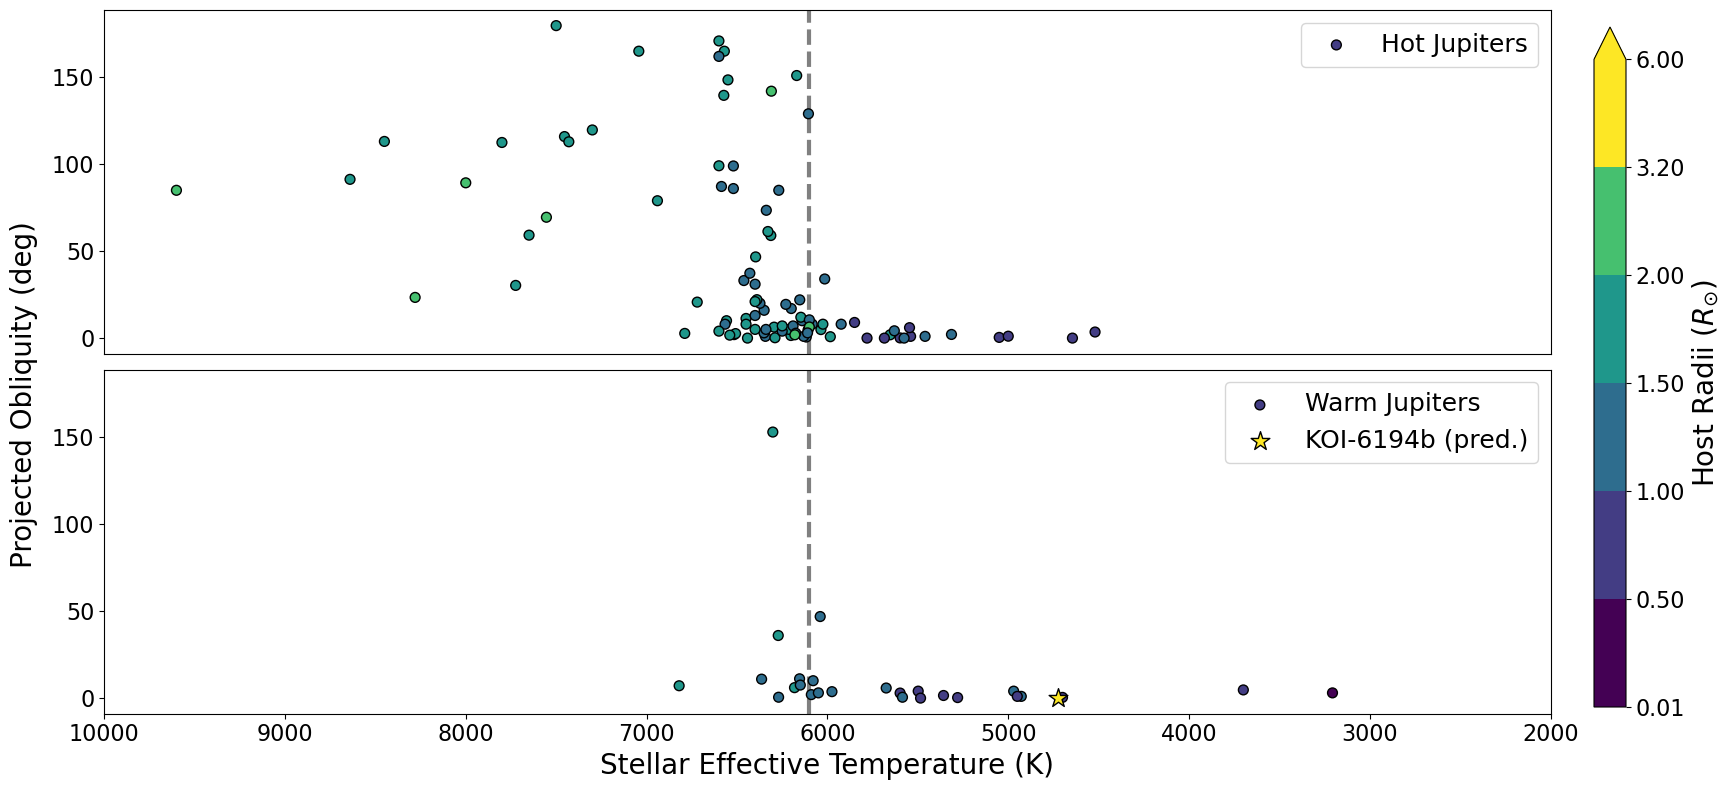

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

ob = pd.read_csv("mod_obliquity_measurements.csv")
txt = pd.read_csv("obliquity_ascii.txt", delimiter="\t")

df = pd.DataFrame({
    "teff": pd.to_numeric(txt["T_eff"].astype(str).str[:4], errors="coerce"),
    "st_rad": pd.to_numeric(txt["R"].astype(str).str[:4], errors="coerce"),
    "pl_rad": pd.to_numeric(ob["r"], errors="coerce"),
    "lam": pd.to_numeric(ob["lambda"], errors="coerce"),
    "a_R": pd.to_numeric(ob["a/R"], errors="coerce"),
    "pl_mass": pd.to_numeric(ob["m"], errors="coerce"),
})

# Drop rows that don't have teff, lam, a_R and st_rad
df = df.dropna(subset=["teff", "lam", "a_R", "st_rad"])

# filtering
mask0 = (df["lam"] < 10) & (df["teff"] > 7500)
mask  = (df["lam"] > 10) & (df["teff"] < 6000)
mask1 = (df["lam"] > 5)  & (df["teff"] < 5500)

df = df.loc[~(mask0 | mask | mask1)].copy()

# Classes
is_hj = df["a_R"] < 10
is_wj = df["a_R"] > 10  
class_mask = np.array([is_hj, is_wj])
class_labels = np.array(["Hot Jupiters", "Warm Jupiters"])
fig, ax = plt.subplots(2,1,figsize=(16, 8), sharey=True)
fontsize = 20

colors = plt.get_cmap('viridis')(np.linspace(0, 1, 256))
new_colors = np.vstack((colors[:200], colors[230:]))  # Remove colors between indices that map to [3.2, 6.0]
new_cmap = ListedColormap(new_colors)
cmap = new_cmap
bounds = np.array([0.01, 0.5, 1, 1.5, 2, 3.2, 6])
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

for i, (jup, jup_lab) in enumerate(zip(class_mask, class_labels)):
    sc = ax[i].scatter(
        df.loc[jup, "teff"],
        df.loc[jup, "lam"],
        c=df.loc[jup, "st_rad"],
        cmap=cmap,
        norm=norm,
        s=50,
        edgecolor='k',
        label=jup_lab,
    )
    if i == 0:
        ax[i].set_xticks([])
    if i == 1:
        ax[i].scatter(KOI6194b[-2], KOI6194b[-1], s=200, c=KOI_rad, cmap=cmap, norm=norm, edgecolor='k', marker='*', label="KOI-6194b (pred.)")
        ax[i].set_xlabel("Stellar Effective Temperature (K)", fontsize=fontsize)
    ax[i].tick_params(axis="both", which="major", labelsize=16)

    ax[i].axvline(6100,c='grey',linestyle='--',linewidth=3.0, zorder=-1)
    ax[i].legend(fontsize=18)
    ax[i].tick_params(axis='both', which='major', labelsize=16)
    ax[i].set_xlim(10000,2000)
fig.supylabel(
    r"Projected Obliquity (deg)",
    fontsize=fontsize,
    x=0.01,  
)
fig.subplots_adjust(right=0.88)

# Explicit colorbar axis: [left, bottom, width, height]
cax = fig.add_axes([
    1,
    0.11,
    0.02,
    0.85,
])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cax,
    extend='max'
)
cbar.set_ticks(bounds)
cbar.set_label(r'Host Radii $(R_{\odot})$',fontsize=fontsize)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()